# **Requirement 1: Single Campaign and Stochastic Environment**

We model the online advertising bidding problem as a Multi-Armed Bandit (MAB).

At each round $t$, an advertiser:
1. Observes an auction opportunity (an impression).
2. Submits a **bid** $b_t$ from a discrete set of bids $\mathcal{B} = \{b^{(1)}, \ldots, b^{(K)}\}$ (arms).
3. Wins the auction if $b_t$ exceeds the **highest competing bid** $c_t$ (drawn i.i.d. from an unknown distribution $F$).
4. If it wins, it pays $c_t$ (first-price) and receives a **value** $v$ (assumed known for a single campaign).
5. The **reward** is: $r_t = (v - c_t) \cdot \mathbf{1}[b_t \geq c_t]$.

The stochastic environment is a distribution over the highest competing bid $c_t$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---
## Part 1: Build a Stochastic Environment

The environment draws the highest competing bid $c_t \sim F$ i.i.d. at each round.

We use a **Beta distribution** scaled to $[0, 1]$ to model $F$ (it is flexible and bounded).

Each arm $b^{(k)}$ corresponds to a specific bid value. When the agent plays arm $k$ (bids $b^{(k)}$), the expected reward is:
$$\mu_k = \mathbb{E}_{c \sim F}[(v - c) \cdot \mathbf{1}[b^{(k)} \geq c]]$$

Since $c_t$ is i.i.d., **the reward for each arm is i.i.d. across rounds** — this is exactly a stochastic MAB.

In [2]:
class Environment:
    """Base environment class."""
    def __init__(self):
        pass

    def round(self, a_t):
        pass

In [3]:
class StochasticBiddingEnvironment(Environment):
    """
    Stochastic bidding environment for a single campaign.

    The highest competing bid c_t is drawn i.i.d. from a Beta distribution
    scaled to [0, max_bid]. Arms correspond to discrete bid values.

    Parameters
    ----------
    bids : array of shape (K,)
        Discrete bid values available to the agent.
    value : float
        The value per impression for the single campaign.
    alpha : float
        Alpha parameter of the Beta distribution for competing bids.
    beta_param : float
        Beta parameter of the Beta distribution for competing bids.
    max_bid : float
        Scale of the competing bid distribution (upper bound).
    T : int
        Time horizon (number of rounds).
    """
    def __init__(self, bids, value, alpha, beta_param, max_bid, T):
        self.bids = bids
        self.K = len(bids)
        self.value = value
        self.max_bid = max_bid
        self.T = T

        # Pre-draw all competing bids from Beta distribution scaled to [0, max_bid]
        self.competing_bids = np.random.beta(alpha, beta_param, size=T) * max_bid
        self.t = 0

    def round(self, a_t):
        """
        Simulate one round.

        Parameters
        ----------
        a_t : int
            Index of the bid chosen by the agent (arm index).

        Returns
        -------
        r_t : float
            Reward: (value - competing_bid) if agent wins, else 0.
        """
        c_t = self.competing_bids[self.t]
        bid = self.bids[a_t]
        # Win if our bid >= competing bid (first-price: pay c_t)
        if bid >= c_t:
            r_t = self.value - c_t
        else:
            r_t = 0.0
        self.t += 1
        return r_t

    def expected_reward(self, a_t, n_samples=100_000):
        """
        Compute the true expected reward for arm a_t via Monte Carlo.
        Used to identify the optimal arm (clairvoyant).
        """
        c_samples = np.random.beta(2, 5, size=n_samples) * self.max_bid
        wins = self.bids[a_t] >= c_samples
        rewards = (self.value - c_samples) * wins
        return rewards.mean()

Bid arms: [0.    0.111 0.222 0.333 0.444 0.556 0.667 0.778 0.889 1.   ]
Value per impression: 1.0
Competing bid ~ Beta(2, 5) x 1.0


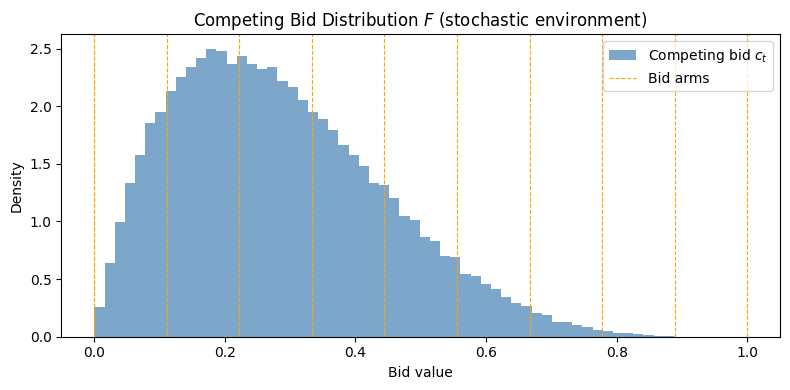

In [4]:
# --- Environment parameters ---
np.random.seed(42)

value    = 1.0          # Value per impression
max_bid  = 1.0          # Maximum bid (bids and competing bids are in [0, 1])
K        = 10           # Number of discrete bid arms
bids     = np.linspace(0, max_bid, K)   # Bid arms: 0.0, 0.11, ..., 1.0
T        = 10_000       # Time horizon

# Competing bid distribution: Beta(2, 5) scaled to [0, 1]
# This creates a left-skewed distribution — most competing bids are low
alpha_dist, beta_dist_param = 2, 5

print(f"Bid arms: {np.round(bids, 3)}")
print(f"Value per impression: {value}")
print(f"Competing bid ~ Beta({alpha_dist}, {beta_dist_param}) x {max_bid}")

# Visualise the competing bid distribution
c_samples = np.random.beta(alpha_dist, beta_dist_param, size=100_000) * max_bid
plt.figure(figsize=(8, 4))
plt.hist(c_samples, bins=60, density=True, alpha=0.7, color='steelblue', label='Competing bid $c_t$')
for b in bids:
    plt.axvline(b, color='orange', linewidth=0.8, linestyle='--')
plt.axvline(bids[0], color='orange', linewidth=0.8, linestyle='--', label='Bid arms')
plt.xlabel('Bid value')
plt.ylabel('Density')
plt.title('Competing Bid Distribution $F$ (stochastic environment)')
plt.legend()
plt.tight_layout()
plt.show()

True expected reward per arm:
  Arm  0 (bid=0.00): mu = 0.0000
  Arm  1 (bid=0.11): mu = 0.1269
  Arm  2 (bid=0.22): mu = 0.3447
  Arm  3 (bid=0.33): mu = 0.5260
  Arm  4 (bid=0.44): mu = 0.6369
  Arm  5 (bid=0.56): mu = 0.6903
  Arm  6 (bid=0.67): mu = 0.7093
  Arm  7 (bid=0.78): mu = 0.7137
  Arm  8 (bid=0.89): mu = 0.7141
  Arm  9 (bid=1.00): mu = 0.7141 <-- OPTIMAL


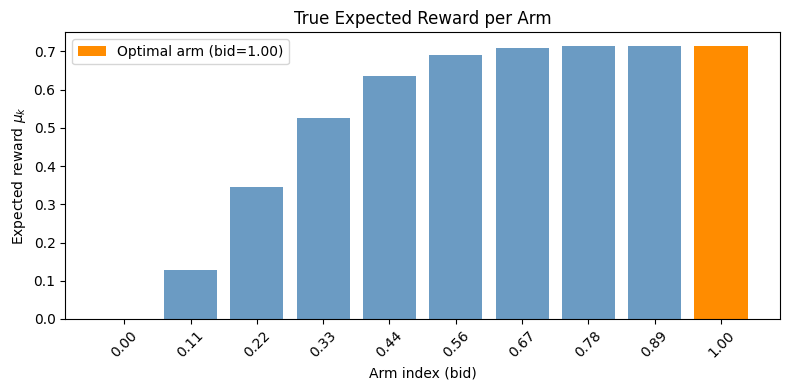

In [5]:
# Compute the true expected reward for each arm (clairvoyant baseline)
c_mc = np.random.beta(alpha_dist, beta_dist_param, size=500_000) * max_bid
true_expected_rewards = np.array([
    np.mean((value - c_mc) * (bids[k] >= c_mc)) for k in range(K)
])

best_arm = np.argmax(true_expected_rewards)
mu_star  = true_expected_rewards[best_arm]

print("True expected reward per arm:")
for k in range(K):
    marker = " <-- OPTIMAL" if k == best_arm else ""
    print(f"  Arm {k:2d} (bid={bids[k]:.2f}): mu = {true_expected_rewards[k]:.4f}{marker}")

plt.figure(figsize=(8, 4))
plt.bar(range(K), true_expected_rewards, color='steelblue', alpha=0.8)
plt.bar(best_arm, true_expected_rewards[best_arm], color='darkorange', label=f'Optimal arm (bid={bids[best_arm]:.2f})')
plt.xlabel('Arm index (bid)')
plt.ylabel('Expected reward $\\mu_k$')
plt.title('True Expected Reward per Arm')
plt.xticks(range(K), [f'{b:.2f}' for b in bids], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 2: Algorithm 1 — UCB1 Ignoring the Budget Constraint

We treat the bidding problem as a standard MAB: at each round pick the arm with the highest **Upper Confidence Bound**:

$$\text{UCB}_k(t) = \hat{\mu}_k(t) + \sqrt{\frac{2 \ln T}{N_k(t)}}$$

where $\hat{\mu}_k(t)$ is the empirical mean reward of arm $k$ after $N_k(t)$ pulls.

This completely **ignores the budget** — the agent may overspend.

In [6]:
class Agent:
    """Base agent class."""
    def __init__(self):
        pass
    def pull_arm(self):
        pass
    def update(self, r_t):
        pass

In [7]:
class UCB1BiddingAgent(Agent):
    """
    UCB1 bidding agent — ignores budget constraint.

    Arms correspond to discrete bids. At each round the agent selects
    the arm with the highest UCB index:

        UCB_k(t) = hat_mu_k + sqrt(2 * log(T) / N_k(t))

    The first K rounds are used to pull each arm once (initialisation).

    Parameters
    ----------
    K : int
        Number of arms (bid values).
    T : int
        Time horizon.
    """
    def __init__(self, K, T):
        self.K = K
        self.T = T
        self.a_t = None
        self.average_rewards = np.zeros(K)   # hat_mu_k
        self.N_pulls = np.zeros(K)            # N_k(t)
        self.t = 0

    def pull_arm(self):
        if self.t < self.K:
            # Initialisation: pull each arm once
            self.a_t = self.t
        else:
            ucbs = self.average_rewards + np.sqrt(2 * np.log(self.T) / self.N_pulls)
            self.a_t = np.argmax(ucbs)
        return self.a_t

    def update(self, r_t):
        self.N_pulls[self.a_t] += 1
        # Incremental mean update
        self.average_rewards[self.a_t] += (
            (r_t - self.average_rewards[self.a_t]) / self.N_pulls[self.a_t]
        )
        self.t += 1

In [8]:
# --- Experiment: UCB1 without budget constraint ---
n_trials = 50
expected_clairvoyant_rewards = np.repeat(mu_star, T)  # clairvoyant always plays best arm

ucb_regret_per_trial   = []
ucb_spend_per_trial    = []

for seed in range(n_trials):
    np.random.seed(seed)
    env       = StochasticBiddingEnvironment(bids, value, alpha_dist, beta_dist_param, max_bid, T)
    ucb_agent = UCB1BiddingAgent(K, T)

    agent_rewards = np.zeros(T)
    agent_costs   = np.zeros(T)   # track spend

    for t in range(T):
        a_t = ucb_agent.pull_arm()
        # Observe reward and also track the cost (bid paid when winning)
        c_t  = env.competing_bids[env.t]
        r_t  = env.round(a_t)
        ucb_agent.update(r_t)

        agent_rewards[t] = r_t
        agent_costs[t]   = c_t if (bids[a_t] >= c_t) else 0.0

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards - agent_rewards)
    ucb_regret_per_trial.append(cumulative_regret)
    ucb_spend_per_trial.append(np.cumsum(agent_costs))

ucb_regret_per_trial = np.array(ucb_regret_per_trial)
ucb_spend_per_trial  = np.array(ucb_spend_per_trial)

ucb_avg_regret = ucb_regret_per_trial.mean(axis=0)
ucb_sd_regret  = ucb_regret_per_trial.std(axis=0)

print(f"UCB1 (no budget): average total regret = {ucb_avg_regret[-1]:.2f} ± {ucb_sd_regret[-1]:.2f}")
print(f"UCB1 (no budget): average total spend  = {ucb_spend_per_trial[:, -1].mean():.2f}")

UCB1 (no budget): average total regret = 205.27 ± 18.74
UCB1 (no budget): average total spend  = 2643.60


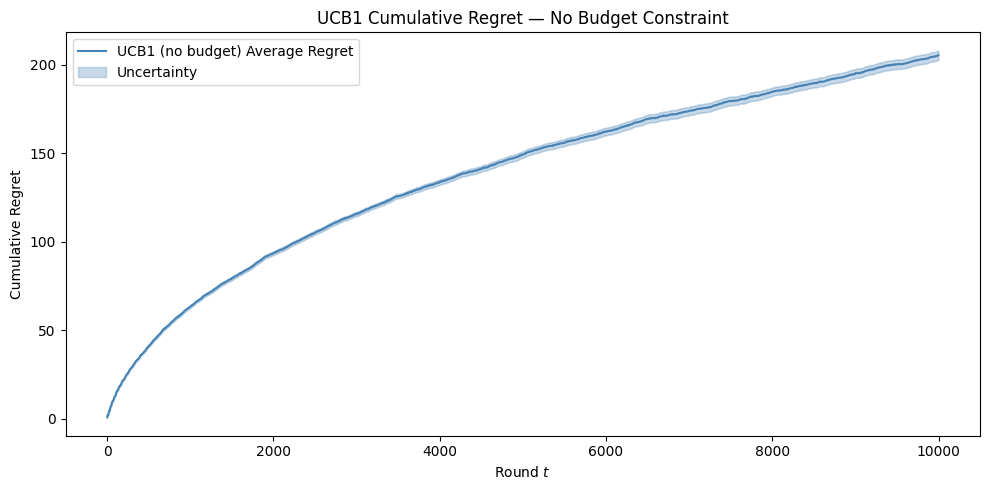

In [9]:
# --- Plot: Cumulative Regret of UCB1 (no budget) ---
plt.figure(figsize=(10, 5))
plt.plot(np.arange(T), ucb_avg_regret, label='UCB1 (no budget) Average Regret', color='steelblue')
plt.fill_between(
    np.arange(T),
    ucb_avg_regret - ucb_sd_regret / np.sqrt(n_trials),
    ucb_avg_regret + ucb_sd_regret / np.sqrt(n_trials),
    alpha=0.3, color='steelblue', label='Uncertainty'
)
plt.xlabel('Round $t$')
plt.ylabel('Cumulative Regret')
plt.title('UCB1 Cumulative Regret — No Budget Constraint')
plt.legend()
plt.tight_layout()
plt.show()

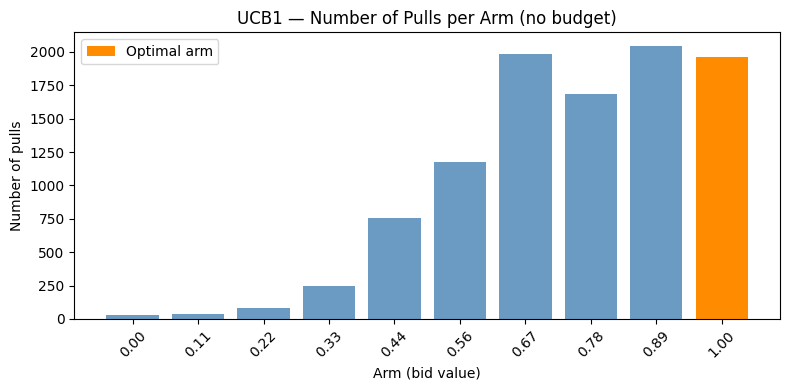

Empirical mean rewards (UCB1, no budget):
  Arm 0 (bid=0.00): hat_mu=0.0000  true_mu=0.0000  N=29
  Arm 1 (bid=0.11): hat_mu=0.1360  true_mu=0.1269  N=41
  Arm 2 (bid=0.22): hat_mu=0.3423  true_mu=0.3447  N=86
  Arm 3 (bid=0.33): hat_mu=0.5324  true_mu=0.5260  N=244
  Arm 4 (bid=0.44): hat_mu=0.6517  true_mu=0.6369  N=754
  Arm 5 (bid=0.56): hat_mu=0.6829  true_mu=0.6903  N=1174
  Arm 6 (bid=0.67): hat_mu=0.7118  true_mu=0.7093  N=1983
  Arm 7 (bid=0.78): hat_mu=0.7035  true_mu=0.7137  N=1684
  Arm 8 (bid=0.89): hat_mu=0.7134  true_mu=0.7141  N=2044
  Arm 9 (bid=1.00): hat_mu=0.7112  true_mu=0.7141  N=1961


In [10]:
# --- Arm pull distribution from a single run ---
np.random.seed(0)
env_single   = StochasticBiddingEnvironment(bids, value, alpha_dist, beta_dist_param, max_bid, T)
ucb_single   = UCB1BiddingAgent(K, T)
for t in range(T):
    a_t = ucb_single.pull_arm()
    r_t = env_single.round(a_t)
    ucb_single.update(r_t)

plt.figure(figsize=(8, 4))
plt.bar(range(K), ucb_single.N_pulls, color='steelblue', alpha=0.8)
plt.bar(best_arm, ucb_single.N_pulls[best_arm], color='darkorange', label=f'Optimal arm')
plt.xticks(range(K), [f'{b:.2f}' for b in bids], rotation=45)
plt.xlabel('Arm (bid value)')
plt.ylabel('Number of pulls')
plt.title('UCB1 — Number of Pulls per Arm (no budget)')
plt.legend()
plt.tight_layout()
plt.show()

print("Empirical mean rewards (UCB1, no budget):")
for k in range(K):
    print(f"  Arm {k} (bid={bids[k]:.2f}): hat_mu={ucb_single.average_rewards[k]:.4f}  true_mu={true_expected_rewards[k]:.4f}  N={int(ucb_single.N_pulls[k])}")

### Remark
UCB1 achieves **sub-linear regret** (the cumulative regret curve bends over). The theoretical upper bound for UCB1 is $O(\sqrt{KT \ln T})$. The agent quickly concentrates pulls on the optimal arm, but with **no budget enforcement**, total spending grows unboundedly.

---
## Part 3: Algorithm 2 — Budget-Constrained UCB1

We now extend UCB1 to respect a **total budget** $B$ (maximum total spend).

**Key idea**: the agent must not only maximise reward, but also *control its spending rate*. We use a **pacing** approach:

- At round $t$, the agent has spent $S_t$ so far and has $B - S_t$ remaining budget.
- It has $T - t$ rounds left.
- It should not bid on arms whose **expected cost** would likely exhaust the budget too fast.
- We filter out arms $k$ whose expected cost $\hat{c}_k$ exceeds the remaining budget per round:
  $$\text{remaining budget per round} = \frac{B - S_t}{T - t}$$
- Among affordable arms, we select the one with the **highest UCB index**.
- If the remaining budget is exhausted ($B - S_t \leq 0$), the agent **stops bidding** (bids arm 0, which has bid 0).

In [11]:
class BudgetUCB1BiddingAgent(Agent):
    """
    Budget-constrained UCB1 bidding agent.

    Extends UCB1 with a pacing mechanism:
    - Tracks cumulative spend.
    - At each round, filters out arms whose estimated cost exceeds the
      remaining budget per round (B - S_t) / (T - t).
    - Among affordable arms, picks the arm with the highest UCB.
    - If budget is exhausted, always bids 0 (arm 0).

    The agent also maintains UCB estimates for the *cost* of each arm,
    to predict whether bidding is affordable.

    Parameters
    ----------
    K : int
        Number of arms.
    T : int
        Time horizon.
    budget : float
        Total budget B.
    """
    def __init__(self, K, T, budget):
        self.K = K
        self.T = T
        self.budget = budget
        self.a_t = None

        # UCB statistics for reward
        self.average_rewards = np.zeros(K)
        self.N_pulls = np.zeros(K)

        # Empirical mean cost per arm (to estimate spending)
        self.average_costs = np.zeros(K)

        self.spent = 0.0   # cumulative spend so far
        self.t = 0

    def pull_arm(self):
        remaining_budget = self.budget - self.spent
        remaining_rounds = self.T - self.t

        # If budget exhausted, bid 0 (arm 0)
        if remaining_budget <= 0 or remaining_rounds <= 0:
            self.a_t = 0
            return self.a_t

        # Initialisation: pull each arm once
        if self.t < self.K:
            self.a_t = self.t
            return self.a_t

        # Budget per round (pacing target)
        budget_per_round = remaining_budget / remaining_rounds

        # Compute UCB indices for reward
        ucbs = self.average_rewards + np.sqrt(2 * np.log(self.T) / self.N_pulls)

        # Mask arms that are (on average) too expensive to sustain
        # An arm is affordable if its average cost <= budget_per_round
        affordable = self.average_costs <= budget_per_round

        if not np.any(affordable):
            # All arms seem too expensive; bid arm 0 (safest/cheapest)
            self.a_t = 0
        else:
            # Among affordable arms, pick highest UCB
            masked_ucbs = np.where(affordable, ucbs, -np.inf)
            self.a_t = np.argmax(masked_ucbs)

        return self.a_t

    def update(self, r_t, cost_t):
        """
        Parameters
        ----------
        r_t : float
            Reward received.
        cost_t : float
            Actual cost paid this round (0 if we lost the auction).
        """
        self.N_pulls[self.a_t] += 1
        self.average_rewards[self.a_t] += (
            (r_t - self.average_rewards[self.a_t]) / self.N_pulls[self.a_t]
        )
        self.average_costs[self.a_t] += (
            (cost_t - self.average_costs[self.a_t]) / self.N_pulls[self.a_t]
        )
        self.spent += cost_t
        self.t += 1

In [12]:
# --- Experiment: Budget-Constrained UCB1 ---

# Set budget to 40% of what an unconstrained agent would spend on average
# (this makes the budget binding and interesting)
avg_cost_optimal = np.mean(
    np.random.beta(alpha_dist, beta_dist_param, size=200_000) * max_bid *
    (bids[best_arm] >= np.random.beta(alpha_dist, beta_dist_param, size=200_000) * max_bid)
)
budget = 0.4 * T * avg_cost_optimal
print(f"Budget B = {budget:.2f}")
print(f"Expected spend of optimal arm over T rounds (no budget): {T * avg_cost_optimal:.2f}")

# Compute clairvoyant reward under budget constraint:
# best fixed arm that can be sustained with budget B
# For simplicity, we use mu_star as an upper bound

budget_ucb_regret_per_trial = []
budget_ucb_spend_per_trial  = []

for seed in range(n_trials):
    np.random.seed(seed)
    env        = StochasticBiddingEnvironment(bids, value, alpha_dist, beta_dist_param, max_bid, T)
    budget_agent = BudgetUCB1BiddingAgent(K, T, budget)

    agent_rewards = np.zeros(T)
    agent_costs   = np.zeros(T)

    for t in range(T):
        a_t  = budget_agent.pull_arm()
        c_t  = env.competing_bids[env.t]
        r_t  = env.round(a_t)
        cost = c_t if (bids[a_t] >= c_t) else 0.0
        budget_agent.update(r_t, cost)

        agent_rewards[t] = r_t
        agent_costs[t]   = cost

    cumulative_regret = np.cumsum(expected_clairvoyant_rewards - agent_rewards)
    budget_ucb_regret_per_trial.append(cumulative_regret)
    budget_ucb_spend_per_trial.append(np.cumsum(agent_costs))

budget_ucb_regret_per_trial = np.array(budget_ucb_regret_per_trial)
budget_ucb_spend_per_trial  = np.array(budget_ucb_spend_per_trial)

budget_avg_regret = budget_ucb_regret_per_trial.mean(axis=0)
budget_sd_regret  = budget_ucb_regret_per_trial.std(axis=0)

print(f"Budget UCB1: average total regret = {budget_avg_regret[-1]:.2f} ± {budget_sd_regret[-1]:.2f}")
print(f"Budget UCB1: average total spend  = {budget_ucb_spend_per_trial[:, -1].mean():.2f} (budget = {budget:.2f})")

Budget B = 1143.33
Expected spend of optimal arm over T rounds (no budget): 2858.34


Budget UCB1: average total regret = 2580.32 ± 239.23
Budget UCB1: average total spend  = 1121.71 (budget = 1143.33)


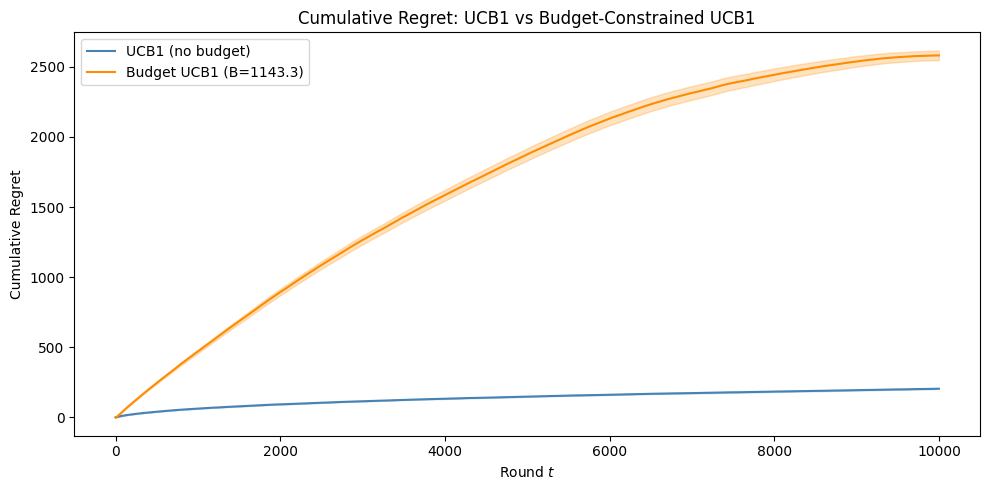

In [13]:
# --- Plot 1: Cumulative Regret Comparison ---
plt.figure(figsize=(10, 5))

plt.plot(np.arange(T), ucb_avg_regret, label='UCB1 (no budget)', color='steelblue')
plt.fill_between(np.arange(T),
    ucb_avg_regret - ucb_sd_regret / np.sqrt(n_trials),
    ucb_avg_regret + ucb_sd_regret / np.sqrt(n_trials),
    alpha=0.25, color='steelblue')

plt.plot(np.arange(T), budget_avg_regret, label=f'Budget UCB1 (B={budget:.1f})', color='darkorange')
plt.fill_between(np.arange(T),
    budget_avg_regret - budget_sd_regret / np.sqrt(n_trials),
    budget_avg_regret + budget_sd_regret / np.sqrt(n_trials),
    alpha=0.25, color='darkorange')

plt.xlabel('Round $t$')
plt.ylabel('Cumulative Regret')
plt.title('Cumulative Regret: UCB1 vs Budget-Constrained UCB1')
plt.legend()
plt.tight_layout()
plt.show()

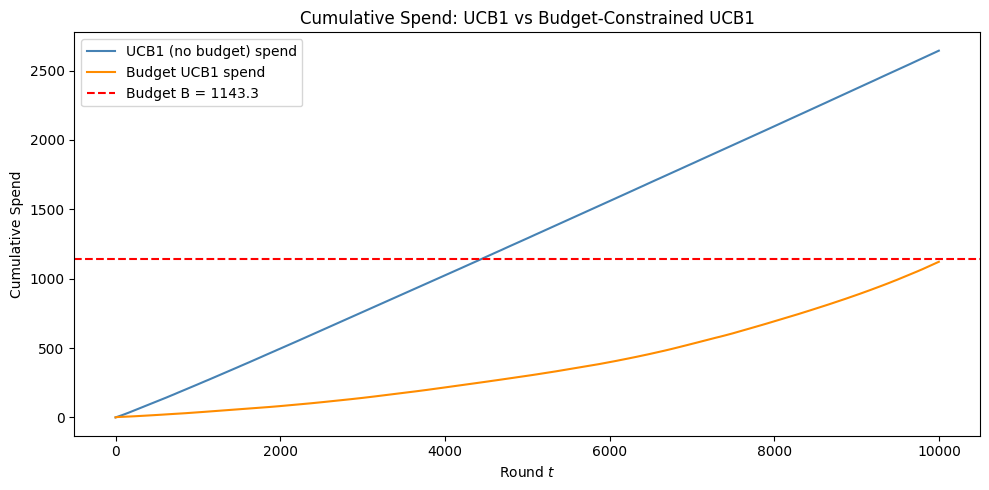


Budget constraint respected: 1143.2063 <= 1143.3342 → YES


In [14]:
# --- Plot 2: Cumulative Spend vs Budget ---
ucb_avg_spend    = ucb_spend_per_trial.mean(axis=0)
budget_avg_spend = budget_ucb_spend_per_trial.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(T), ucb_avg_spend,    label='UCB1 (no budget) spend',     color='steelblue')
plt.plot(np.arange(T), budget_avg_spend, label='Budget UCB1 spend',           color='darkorange')
plt.axhline(budget, color='red', linestyle='--', label=f'Budget B = {budget:.1f}')
plt.xlabel('Round $t$')
plt.ylabel('Cumulative Spend')
plt.title('Cumulative Spend: UCB1 vs Budget-Constrained UCB1')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBudget constraint respected: {budget_ucb_spend_per_trial[:, -1].max():.4f} <= {budget:.4f} "
      f"→ {'YES' if budget_ucb_spend_per_trial[:, -1].max() <= budget + 1e-6 else 'VIOLATED'}")

### Remarks

1. **UCB1 without budget** achieves lower regret (it can always play the optimal arm) but **ignores total spending** — cumulative spend grows linearly and may exceed any fixed budget.

2. **Budget-constrained UCB1** enforces the budget via pacing: it filters out arms that are too expensive given the remaining budget. As a result:
   - Total spend stays **below $B$**.
   - Regret is higher: the agent must sometimes forgo the optimal bid to stay within budget.
   - The sub-linear shape is preserved whenever the budget is sufficient for a good-enough arm to be played most of the time.

3. The regret measured here is against the **unconstrained clairvoyant** (always plays the best arm). A tighter benchmark would be the best arm affordable within budget.